In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "AB_NYC_2019.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dgomonov/new-york-city-airbnb-open-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df


/tmp/ipykernel_1619/2027778552.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [ ]:
#clean the data
df.columns = df.columns.str.strip() #convert everything in string
df = df.drop_duplicates(subset=['id', 'name'], keep='first') #delete the duplicates in "id" and "name"
df = df[df['availability_365'] > 0] #delete the avalability 0
df.fillna(0, inplace=True) #replace the nan by 0
  #delete the negative prices negative or in 0
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df[df['price'] > 0]

   #reset the index
df = df.reset_index(drop=True)

# check the dataset after the cleaning:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Total_Crimes
0,2539,Clean & quiet apt home by the park,2787,John,BROOKLYN,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,162387
1,2595,Skylit Midtown Castle,2845,Jennifer,MANHATTAN,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,136768
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,MANHATTAN,Harlem,40.80902,-73.94190,Private room,150,3,0,0,0.00,1,365,136768
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,BROOKLYN,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,162387
4,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,MANHATTAN,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,136768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31349,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,BROOKLYN,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0,0.00,2,9,162387
31350,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,BROOKLYN,Bushwick,40.70184,-73.93317,Private room,40,4,0,0,0.00,2,36,162387
31351,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,MANHATTAN,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0,0.00,1,27,136768
31352,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,MANHATTAN,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0,0.00,6,2,136768


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31354 entries, 0 to 31353
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              31354 non-null  int64  
 1   name                            31350 non-null  object 
 2   host_id                         31354 non-null  int64  
 3   host_name                       31346 non-null  object 
 4   neighbourhood_group             31354 non-null  object 
 5   neighbourhood                   31354 non-null  object 
 6   latitude                        31354 non-null  float64
 7   longitude                       31354 non-null  float64
 8   room_type                       31354 non-null  object 
 9   price                           31354 non-null  int64  
 10  minimum_nights                  31354 non-null  int64  
 11  number_of_reviews               31354 non-null  int64  
 12  last_review                     

In [ ]:
missing_1 = df[df["last_review"].isna()]
print(missing_1)

             id                                               name   host_id  \
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
15         7750                  Huge 2 BR Upper East  Cental Park     17985   
30        11452                        Clean and Quiet in Brooklyn      7355   
32        11943                          Country space in the city     45445   
182       54466                Beautiful Uptown Manhattan apartmnt    253385   
...         ...                                                ...       ...   
31349  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
31350  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
31351  36485431            Sunny Studio at Historical Neighborhood  23492952   
31352  36485609               43rd St. Time Square-cozy single bed  30985759   
31353  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

           host_name neighbourhood_grou

In [ ]:
#check the district price mean and also order them:
expensive_ng = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

# show the results:
print("Average price per district:")
print(expensive_ng.to_string(index=True, float_format="{:.2f}$".format))
print("------------------------------------------------------------------------")


# check the neighbourhood price mean ans also order them:
counts = df.groupby(['neighbourhood_group', 'neighbourhood']).size() #count the number of announces
means = df.groupby(['neighbourhood_group', 'neighbourhood'])['price'].mean() #average price per neighbourhood
r_neighbourhood = pd.DataFrame({'average price': means, '# anounces': counts}) #create the data frama
top_real = r_neighbourhood[r_neighbourhood['# anounces'] > 5].reset_index() #filter the neighbourhoods with more than 5 announces in order to avoid that one with one high price announce doesnt reflex the reality
top_real = top_real.sort_values(by='average price', ascending=False).drop_duplicates('neighbourhood_group') #order the values
  #order from 1-5 the index:
top_real = top_real.reset_index(drop=True)
top_real.index = top_real.index + 1
# ------------------------------------------

print("More expensive neighbourhood by district:")
print(top_real[['neighbourhood_group', 'neighbourhood', 'average price']])


Average price per district:
neighbourhood_group
MANHATTAN       214.20$
BROOKLYN        132.93$
STATEN ISLAND   114.23$
QUEENS          100.03$
BRONX            89.11$
------------------------------------------------------------------------
More expensive neighbourhood by district:
  neighbourhood_group  neighbourhood  average price
1               BRONX      Riverdale     567.250000
2           MANHATTAN        Tribeca     561.462810
3       STATEN ISLAND  Randall Manor     336.000000
4            BROOKLYN    Cobble Hill     242.155172
5              QUEENS        Arverne     175.095890


In [ ]:
import pandas as pd
import requests

#URL of the API:
url = "https://data.cityofnewyork.us/resource/5uac-w243.json"

# Ask for the data
params = {
    "$select": "boro_nm, count(cmplnt_num)", #boro_nm= district, complnt_num(# of complains)
    "$group": "boro_nm" #group by district
}

response = requests.get(url, params=params)

# create the data frame
district_dangerous = pd.DataFrame(response.json())
#rename the columns:
district_dangerous.columns = ['District', 'Total_Crimes']

#clean and modify the data
district_dangerous.columns = ['District', 'Total_Crimes'] #rename the data
district_dangerous['District'] = district_dangerous['District'].astype(str).str.strip().str.upper() #convert all the district to string
    #filter by the 5 districts that the have in our dataset
districts_ny = ['MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'STATEN ISLAND']
district_dangerous = district_dangerous[district_dangerous['District'].isin(districts_ny)]

district_dangerous['Total_Crimes'] = pd.to_numeric(district_dangerous['Total_Crimes']) #convert to number the number of crimes

#have the index from 1-5 in ascending
district_dangerous = district_dangerous.sort_values(by='Total_Crimes', ascending=False)
district_dangerous = district_dangerous.reset_index(drop=True)
district_dangerous.index = district_dangerous.index + 1

#show the results:
print("Ranking of the danger of districts:")
print(district_dangerous.sort_values(by='Total_Crimes', ascending=False))
print (" ")
print ("--"*40)

#table most frequent type crime per district
crime_data = {
    'neighbourhood_group': ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND'],
    'Most_Common_Crime': ['HARRASSMENT', 'PETIT LARCENY', 'PETIT LARCENY', 'PETIT LARCENY', 'HARRASSMENT']
} #create the dictionary
df_crime_types = pd.DataFrame(crime_data)
df['neighbourhood_group'] = df['neighbourhood_group'].str.upper() #standarize the data
  #merge the dara
df_merged_crimes = pd.merge(
    df[['neighbourhood_group']].drop_duplicates(),
    df_crime_types,
    on='neighbourhood_group',
    how='left'
)
df_merged_crimes = df_merged_crimes.sort_values(by='neighbourhood_group') #order the data

print(" Most common crime by neighborhood")
print(df_merged_crimes.to_string(index=False))

import seaborn as sns
import matplotlib.pyplot as plt



Ranking of the danger of districts:
        District  Total_Crimes
1       BROOKLYN        162387
2      MANHATTAN        136768
3          BRONX        130360
4         QUEENS        124472
5  STATEN ISLAND         24215
 
--------------------------------------------------------------------------------
 Most common crime by neighborhood
neighbourhood_group Most_Common_Crime
              BRONX       HARRASSMENT
           BROOKLYN     PETIT LARCENY
          MANHATTAN     PETIT LARCENY
             QUEENS     PETIT LARCENY
      STATEN ISLAND       HARRASSMENT


In [ ]:
#merge the data
  #convert district of api and dataset in uper
df['neighbourhood_group'] = df['neighbourhood_group'].astype(str).str.strip().str.upper()
district_dangerous['District'] = district_dangerous['District'].astype(str).str.strip().str.upper()
  #delete the previous columns variables:
cols_notused = ['Total_Crimes', 'District', 'Total_Crimes_x', 'Total_Crimes_y']
df = df.drop(columns=[c for c in cols_notused if c in df.columns])
  #start the merge
df = pd.merge(
    df,
    district_dangerous[['District', 'Total_Crimes']],
    left_on='neighbourhood_group',
    right_on='District',
    how='left'
)

# delete the column district
if 'District' in df.columns:
    df = df.drop(columns=['District'])

df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Total_Crimes
0,2539,Clean & quiet apt home by the park,2787,John,BROOKLYN,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,162387
1,2595,Skylit Midtown Castle,2845,Jennifer,MANHATTAN,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,136768
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,MANHATTAN,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,136768
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,BROOKLYN,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,162387
4,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,MANHATTAN,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,136768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31349,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,BROOKLYN,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9,162387
31350,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,BROOKLYN,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36,162387
31351,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,MANHATTAN,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27,136768
31352,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,MANHATTAN,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2,136768


In [ ]:
missing_indices = df["last_review"].isna().sum()
print(missing_indices)

0


In [ ]:
# Comparative table between the price and criminality
final_table = df.groupby('neighbourhood_group').agg({ #group by district
    'price': 'mean',
    'Total_Crimes': 'first' #number of crimes
}).reset_index()

# Customize the table
final_table.columns = ['District', 'Avg_Price', 'Total_Crimes'] #the columns that we want to show
final_table = final_table.sort_values(by='Avg_Price', ascending=False).reset_index(drop=True) #order
final_table.index = final_table.index + 1 #order the index

print("Comparative table: price vs criminality in the different districts")
print(final_table.to_string(float_format="{:.2f}$".format))





Comparative table: price vs criminality in the different districts
        District  Avg_Price  Total_Crimes
1      MANHATTAN    214.20$        136768
2       BROOKLYN    132.93$        162387
3  STATEN ISLAND    114.23$         24215
4         QUEENS    100.03$        124472
5          BRONX     89.11$        130360


/tmp/ipykernel_1619/2099661275.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


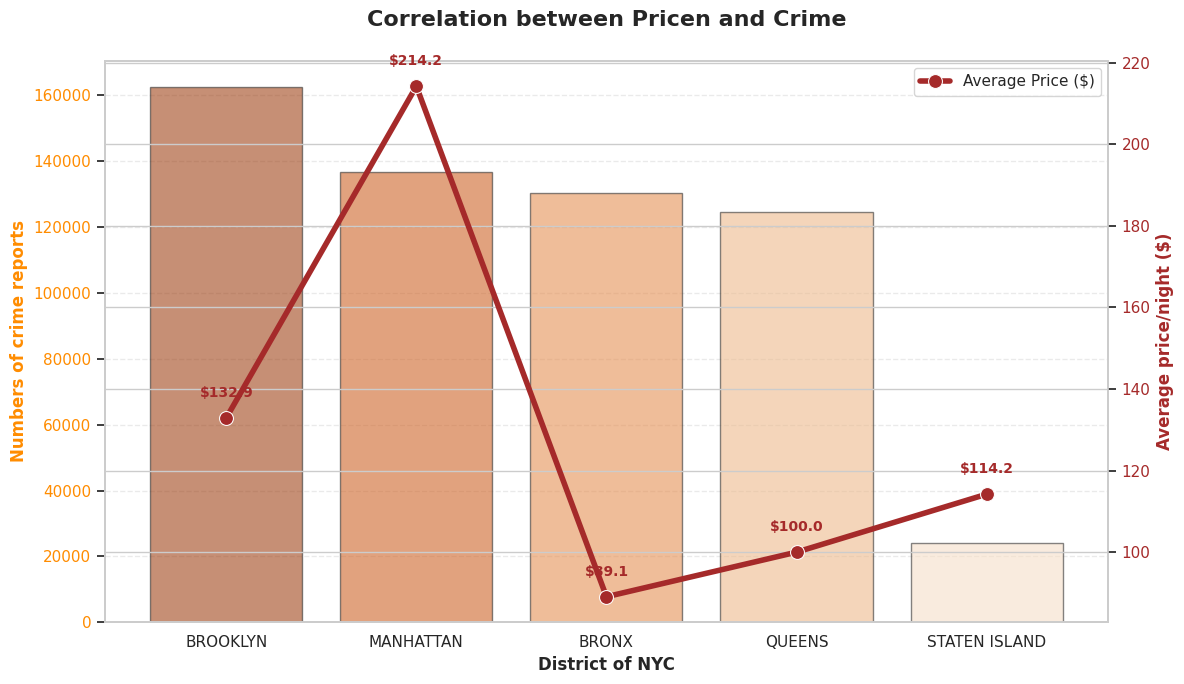

In [ ]:
# graffic:
import matplotlib.pyplot as plt
import seaborn as sns

# order the data
final_table_sorted = final_table.sort_values('Total_Crimes', ascending=False)

# customize the chart
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 7))

# Crime:
sns.barplot(
    x='District',
    y='Total_Crimes',
    data=final_table_sorted,
    ax=ax1,
    palette='Oranges_r',
    alpha=0.6,
    edgecolor=".2"
)

ax1.set_xlabel('District of NYC', fontsize=12, fontweight='bold')
ax1.set_ylabel('Numbers of crime reports', color='darkorange', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='darkorange')

# Price:
ax2 = ax1.twinx()
sns.lineplot(
    x='District',
    y='Avg_Price',
    data=final_table_sorted,
    marker='o',
    color='brown',
    linewidth=4,
    markersize=10,
    ax=ax2,
    label='Average Price ($)'
)

ax2.set_ylabel('Average price/night ($)', color='brown', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='brown')


for i, price in enumerate(final_table_sorted['Avg_Price']):
    ax2.annotate(f'${price:.1f}',
                 (i, final_table_sorted['Avg_Price'].iloc[i]),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontsize=10,
                 fontweight='bold',
                 color='brown')

plt.title('Correlation between Pricen and Crime', fontsize=16, pad=25, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

KeyError: 0

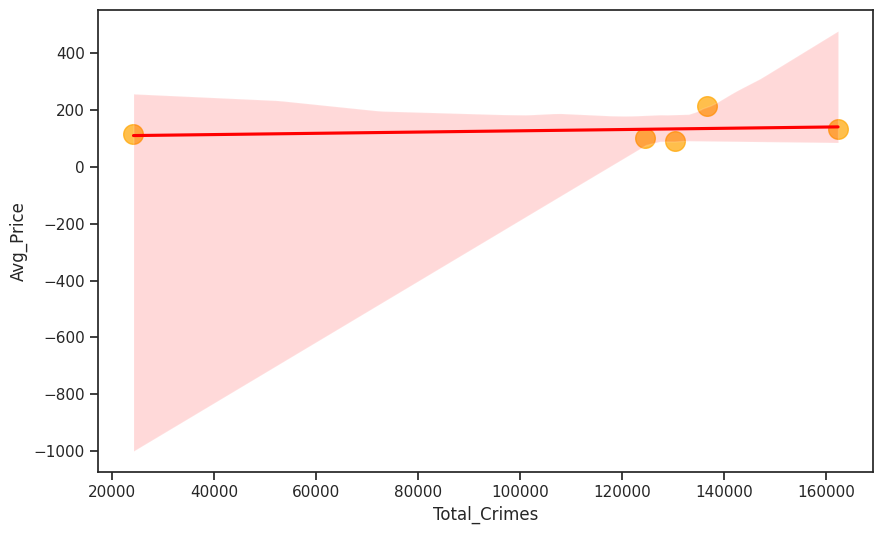

In [ ]:
#dispertion table:
import matplotlib.pyplot as plt
import seaborn as sns

# Customize the stily
sns.set_theme(style="ticks")
plt.figure(figsize=(10, 6))

# Create the graffic
plot = sns.regplot(x='Total_Crimes', y='Avg_Price', data=final_table,
                   scatter_kws={'s': 200, 'color': 'orange', 'alpha': 0.7},
                   line_kws={'color': 'red', 'label': 'Tendencia de la Hipótesis'})
  #name of districts:
for i in range(final_table.shape[0]):
    plt.text(final_table.Total_Crimes[i] + 500, final_table.Avg_Price[i],
             final_table.District[i], fontsize=11, weight='bold')

# 2. Renombramos columnas
tabla_final.columns = ['District', 'Avg_Price', 'Total_Crimes']

# 3. ESTA ES LA PARTE CLAVE: Ordenar y resetear el índice
tabla_final = tabla_final.sort_values(by='Total_Crimes').reset_index(drop=True)

  #Titles:
plt.title('Hypothesis Validation: Does Crime Influence Price?', fontsize=15, pad=20)
plt.xlabel('Number of Police Reports (Crime)', fontsize=12)
plt.ylabel('Average Price /Night ($)', fontsize=12)
plt.legend()
sns.despine()

plt.show()

In [ ]:
# Calculate coeficient:
df_hipotesis = df.groupby('neighbourhood_group').agg({
    'price': 'mean',
    'Total_Crimes': 'first'
}).reset_index()
crime_rel = df_hipotesis['Total_Crimes'].corr(df_hipotesis['price'])

print(f"Coeficient Pearson: {crime_rel :.4f}")

Coeficient Pearson: 0.2355


Number of room type
      Room Type  Listing Count  Percentage (%)
Entire home/apt          16532           52.73
   Private room          13960           44.52
    Shared room            862            2.75
 
 
--------------------------------------------------------------------------------
 
 
 
 ROOM TYPE DISTRIBUTION BY DISTRICT
room_type            Entire home/apt  Private room  Shared room  Total
neighbourhood_group                                                   
MANHATTAN                       8441          4782          336  13559
BROOKLYN                        6071          5876          306  12253
QUEENS                          1550          2586          162   4298
BRONX                            318           545           50    913
STATEN ISLAND                    152           171            8    331
 
 
--------------------------------------------------------------------------------
 
 
 


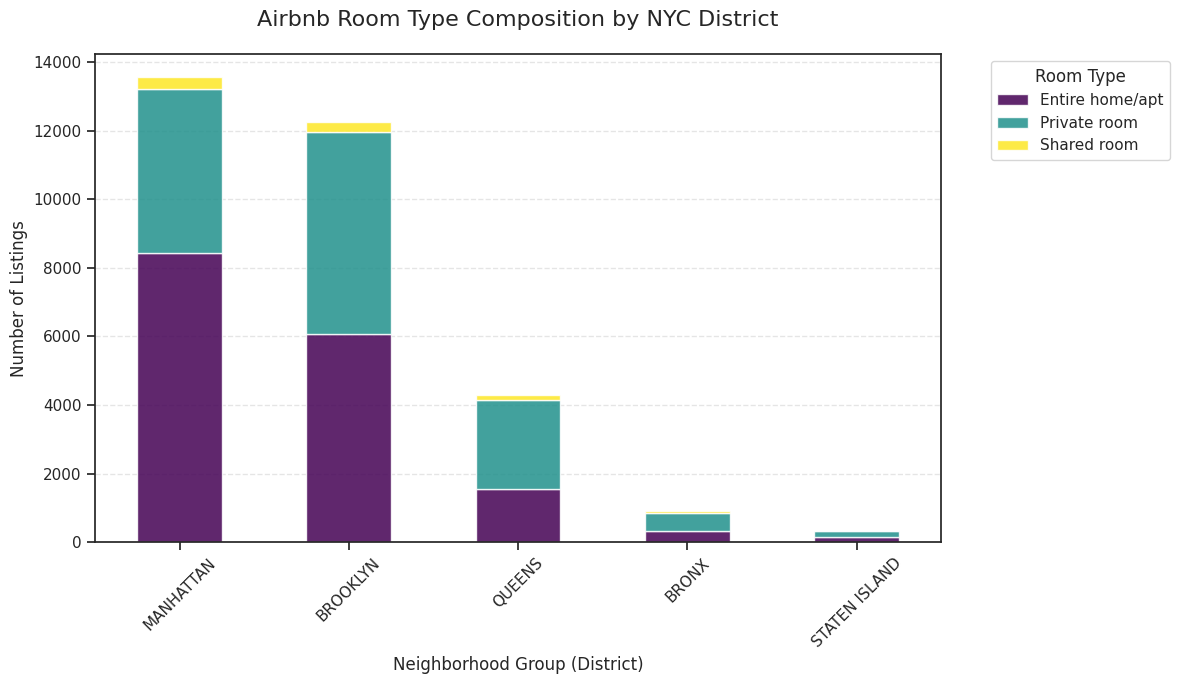

In [ ]:
# Table: # of room tipe:
room_type_summary = df['room_type'].value_counts().reset_index()
room_type_summary.columns = ['Room Type', 'Listing Count']
  #add %
room_type_summary['Percentage (%)'] = (room_type_summary['Listing Count'] / room_type_summary['Listing Count'].sum() * 100).round(2)
print("Number of room type")
print(room_type_summary.to_string(index=False))
print(" ")
print(" ")
print("--"*40)
print(" ")
print(" ")
import pandas as pd

# 2. Count of each room type per district
# We use pd.crosstab to create the distribution matrix
district_room_dist = pd.crosstab(df['neighbourhood_group'], df['room_type'])

# Add a Total column to see the size of each district
district_room_dist['Total'] = district_room_dist.sum(axis=1)

# Sort by districts with the most listings
district_room_dist = district_room_dist.sort_values(by='Total', ascending=False)

print(" ")
print(" ROOM TYPE DISTRIBUTION BY DISTRICT")
print(district_room_dist)
print(" ")
print(" ")
print("--"*40)
print(" ")
print(" ")
print(" ")

import matplotlib.pyplot as plt

# We plot the distribution (excluding the 'Total' column for the bars)
district_room_dist.drop(columns='Total').plot(kind='bar',
                                              stacked=True,
                                              figsize=(12, 7),
                                              colormap='viridis',
                                              alpha=0.85)

# Formatting the chart
plt.title('Airbnb Room Type Composition by NYC District', fontsize=16, pad=20)
plt.xlabel('Neighborhood Group (District)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1619/3126479457.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.annotate(f"${txt:.1f}", (df_room_mixed.index[i], df_room_mixed['price'][i]),


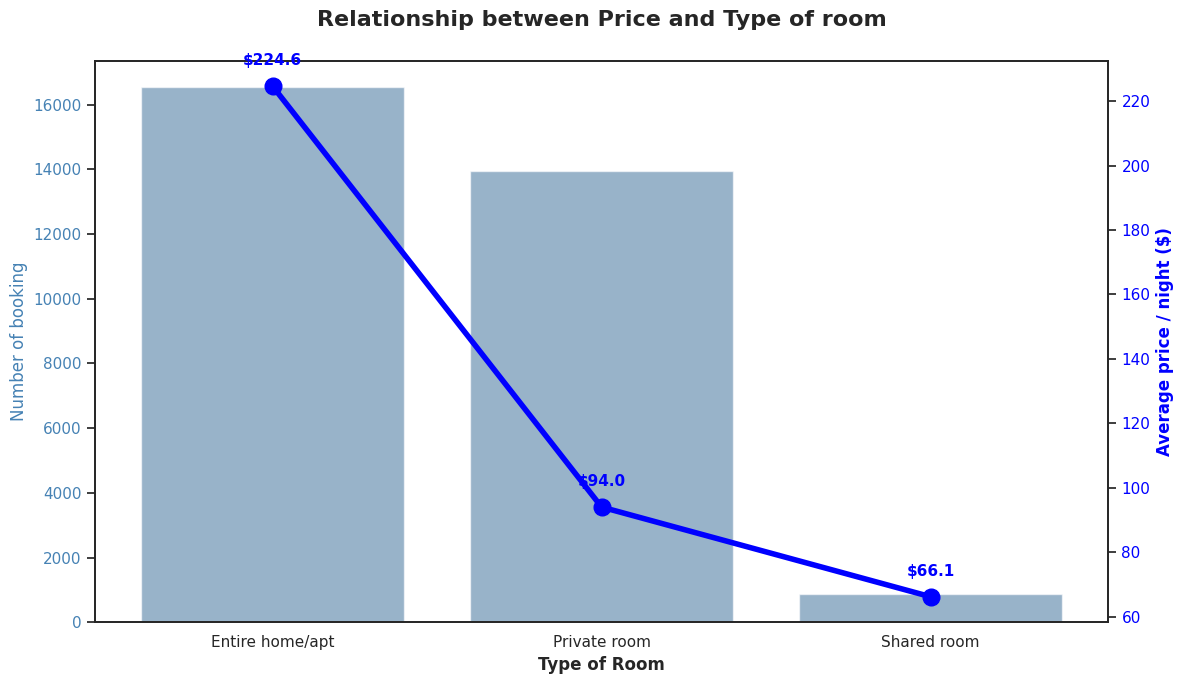

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# count the type of rooms and the average price
df_room_mixed = df.groupby('room_type').agg({
    'price': 'mean',
    'neighbourhood_group': 'count'
}).rename(columns={'neighbourhood_group': 'room_count'}).sort_values('price', ascending=False)

# create the chart
fig, ax1 = plt.subplots(figsize=(12, 7))
sns.set_style("white")

# type of room
color_barra = 'steelblue'
ax1.set_xlabel('Type of Room', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of booking', color='steelblue', fontsize=12)
sns.barplot(x=df_room_mixed.index, y=df_room_mixed['room_count'], ax=ax1, color=color_barra, alpha=0.6)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line
ax2 = ax1.twinx()
color_line = 'blue'
ax2.set_ylabel('Average price / night ($)', color=color_line, fontsize=12, fontweight='bold')
ax2.plot(df_room_mixed.index, df_room_mixed['price'], color=color_line, marker='o', linewidth=4, markersize=12, label='Average price')
ax2.tick_params(axis='y', labelcolor=color_line)
for i, txt in enumerate(df_room_mixed['price']):
    ax2.annotate(f"${txt:.1f}", (df_room_mixed.index[i], df_room_mixed['price'][i]),
                 textcoords="offset points", xytext=(0,15), ha='center',
                 fontsize=11, fontweight='bold', color=color_line)

# 5. Título y diseño
plt.title('Relationship between Price and Type of room', fontsize=16, pad=25, fontweight='bold')
fig.tight_layout()

plt.show()

/tmp/ipykernel_1619/3301381277.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_1619/3301381277.py:24: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_1619/3301381277.py:24: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


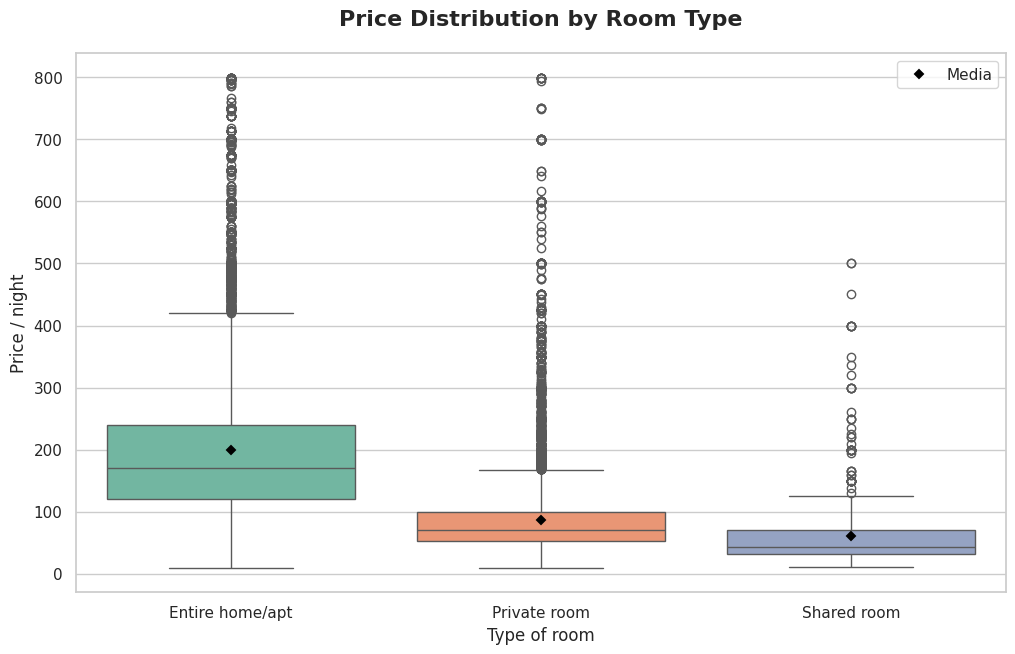

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Customize:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create the box flot Boxplot
df_filtered = df[df['price'] < 800] #filter

ax = sns.boxplot(
    x='room_type',
    y='price',
    data=df_filtered,
    palette='Set2',
    order=['Entire home/apt', 'Private room', 'Shared room']
)

plt.title('Price Distribution by Room Type', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Type of room', fontsize=12)
plt.ylabel('Price / night', fontsize=12)

# average price
sns.pointplot(
    x='room_type',
    y='price',
    data=df_filtered,
    color='black',
    join=False,
    estimator='mean',
    markers='D',
    scale=0.7,
    label='Media'
)

plt.show()

In [ ]:
import pandas as pd

#create the correlation coefficient
room_map = {
    'Entire home/apt': 3,
    'Private room': 2,
    'Shared room': 1
}
df['room_type_rank'] = df['room_type'].map(room_map)
room_correlation = df['room_type_rank'].corr(df['price'])

print(f"Pearson correlation coefficient: {room_correlation:.4f}")

Pearson correlation coefficient: 0.2534


In [ ]:
# import the API:
url = "https://data.ny.gov/resource/39hk-dx4f.json"
response = requests.get(url)

# create the data frame
df_stations = pd.DataFrame(stations_data)

# filter by the district that we have in our dataset
borough_map = {
    'M': 'Manhattan',
    'Bk': 'Brooklyn',
    'Bx': 'Bronx',
    'Q': 'Queens',
    'SI': 'Staten Island'
}
df_stations['neighbourhood_group'] = df_stations['borough'].map(borough_map)

# Order the dataframe
stations_count = df_stations.groupby('neighbourhood_group').size().reset_index(name='subway_station_count')
stations_count = stations_count.sort_values(by='subway_station_count', ascending=False).reset_index(drop=True)
stations_count.index = stations_count.index + 1
stations_count.index.name = 'metro_ranking'

print("Quantity of metro stations in the different cities:")
print("   ")
print(stations_count)

Quantity of metro stations in the different cities:
   
              neighbourhood_group  subway_station_count
metro_ranking                                          
1                        Brooklyn                   169
2                       Manhattan                   153
3                          Queens                    83
4                           Bronx                    70
5                   Staten Island                    21


In [ ]:
#merge the API with the data
import pandas as pd
import requests

  # convert the distrists in capital letters
df['neighbourhood_group'] = df['neighbourhood_group'].astype(str).str.strip().str.upper()
stations_count['District_Metro'] = stations_count['District_Metro'].astype(str).str.strip().str.upper()

  # delete the duplicate colummns
cols_notused_metro = ['subway_station_count', 'District_Metro']
df = df.drop(columns=[c for c in cols_notused_metro if c in df.columns])

  #  Add the column stations counts
df = pd.merge(
    df,
    stations_count[['District_Metro', 'subway_station_count']],
    left_on='neighbourhood_group',
    right_on='District_Metro',
    how='left'
)

df = df.drop(columns=['District_Metro'])
df['subway_station_count'] = df['subway_station_count'].fillna(0).astype(int)

df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Total_Crimes,host_type,subway_station_count
0,2539,Clean & quiet apt home by the park,2787,John,BROOKLYN,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365,162387,multiple_listings,169
1,2595,Skylit Midtown Castle,2845,Jennifer,MANHATTAN,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,136768,multiple_listings,153
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,MANHATTAN,Harlem,Private room,150,3,0,0,0.00,1,365,136768,single_listings,153
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,BROOKLYN,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,162387,single_listings,169
4,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,MANHATTAN,Murray Hill,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,136768,single_listings,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31349,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,BROOKLYN,Bedford-Stuyvesant,Private room,70,2,0,0,0.00,2,9,162387,multiple_listings,169
31350,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,BROOKLYN,Bushwick,Private room,40,4,0,0,0.00,2,36,162387,multiple_listings,169
31351,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,MANHATTAN,Harlem,Entire home/apt,115,10,0,0,0.00,1,27,136768,single_listings,153
31352,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,MANHATTAN,Hell's Kitchen,Shared room,55,1,0,0,0.00,6,2,136768,multiple_listings,153


/tmp/ipykernel_1619/1787213137.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.annotate(f"${txt:.1f}", (df_mixto.index[i], df_mixto['price'][i]),


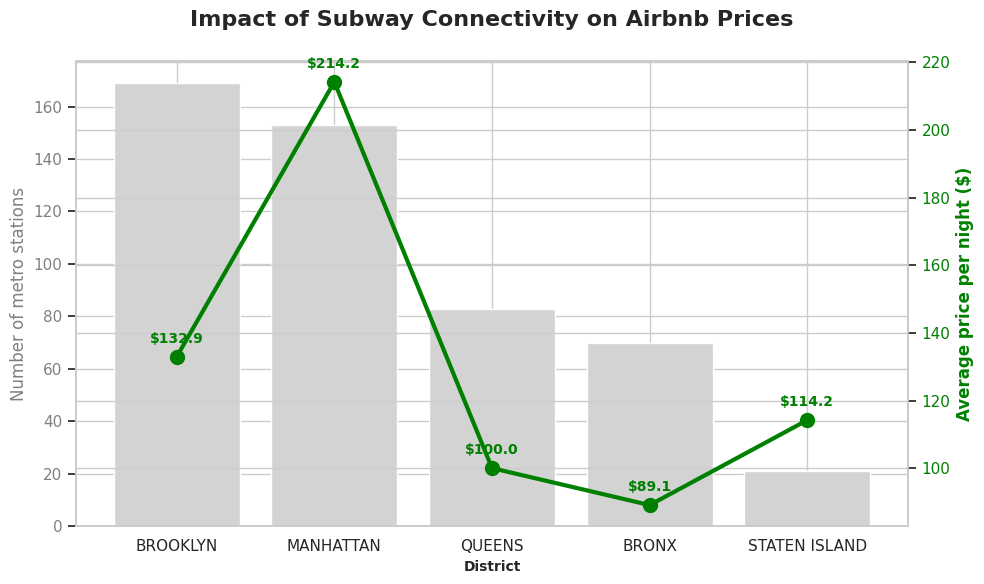

In [ ]:
#chart grafic price and metro station correlation:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of metro and the mean of it
df_mixto = df.groupby('neighbourhood_group').agg({
    'price': 'mean',
    'subway_station_count': 'first'
}).sort_values('subway_station_count', ascending=False)

# Create the chart:
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")

# number of metro station
color_chart = '#D3D3D3'
ax1.set_xlabel('District', fontsize=10, fontweight='bold')
ax1.set_ylabel('Number of metro stations', color='gray', fontsize=12)
chart = ax1.bar(df_mixto.index, df_mixto['subway_station_count'], color=color_chart, label='Number of metro stations')
ax1.tick_params(axis='y', labelcolor='gray')

# price
ax2 = ax1.twinx()
color_line = 'green'
ax2.set_ylabel('Average price per night ($)', color=color_line, fontsize=12, fontweight='bold')
ax2.plot(df_mixto.index, df_mixto['price'], color=color_line, marker='o', linewidth=3, markersize=10, label='Average price')
ax2.tick_params(axis='y', labelcolor=color_line)
for i, txt in enumerate(df_mixto['price']):
    ax2.annotate(f"${txt:.1f}", (df_mixto.index[i], df_mixto['price'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center',
                 fontsize=10, fontweight='bold', color=color_line)

# 6. Título y diseño final
plt.title('Impact of Subway Connectivity on Airbnb Prices', fontsize=16, pad=25, fontweight='bold')
fig.tight_layout()

plt.show()

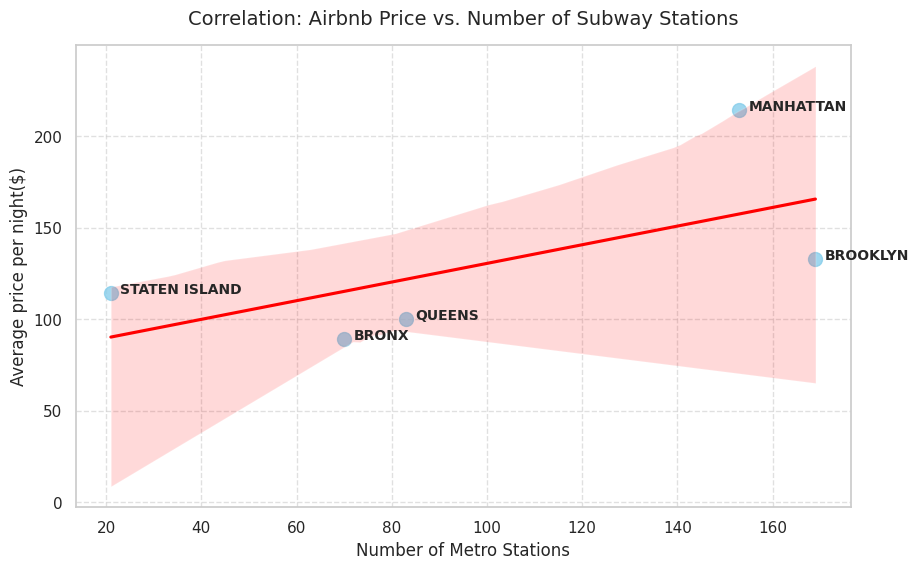

Pearson correlation coefficient: 0.63


In [ ]:
#correlation graffic:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the mean of the variables:
df_corr = df.groupby('neighbourhood_group').agg({
    'price': 'mean',
    'subway_station_count': 'first'
}).reset_index()

# Create the graffic:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.regplot(
    x='subway_station_count',
    y='price',
    data=df_corr,
    scatter_kws={'s': 100, 'color': 'skyblue'},
    line_kws={'color': 'red', 'label': 'Tendencia'}
)

for i in range(df_corr.shape[0]):
    plt.text(
        df_corr.subway_station_count[i] + 2,
        df_corr.price[i],
        df_corr.neighbourhood_group[i],
        fontsize=10,
        fontweight='bold'
    )

plt.title('Correlation: Airbnb Price vs. Number of Subway Stations', fontsize=14, pad=15)
plt.xlabel('Number of Metro Stations', fontsize=12)
plt.ylabel('Average price per night($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Opcional: Calcular el coeficiente de correlación numérico
correlation = df_corr['subway_station_count'].corr(df_corr['price'])
print(f"Pearson correlation coefficient: {correlation:.2f}")

In [ ]:
#Calculate correlation
correlation = df["number_of_reviews"].corr(df["price"])
print(f"Correlation: {correlation: .4f}" )

Correlation: -0.0729


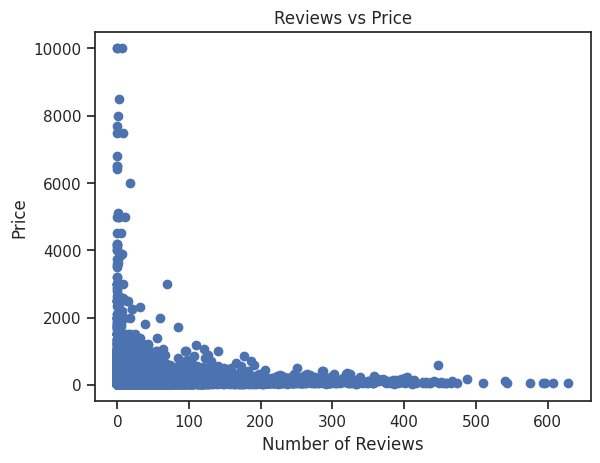

In [ ]:
import matplotlib.pyplot as plt

# Simple scatter plot
plt.scatter(df["number_of_reviews"], df["price"])

# Labels
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.title("Reviews vs Price")

# Show chart
plt.show()

In [ ]:
# Show only the two selected room types
df_h4 = df[df["room_type"].isin(["Entire home/apt", "Private room"])]

# Count how many listings in each room type
print(df_h4["room_type"].value_counts())

room_type
Entire home/apt    16532
Private room       13960
Name: count, dtype: int64


Entire home/apt: 224.61
Private room: 93.97


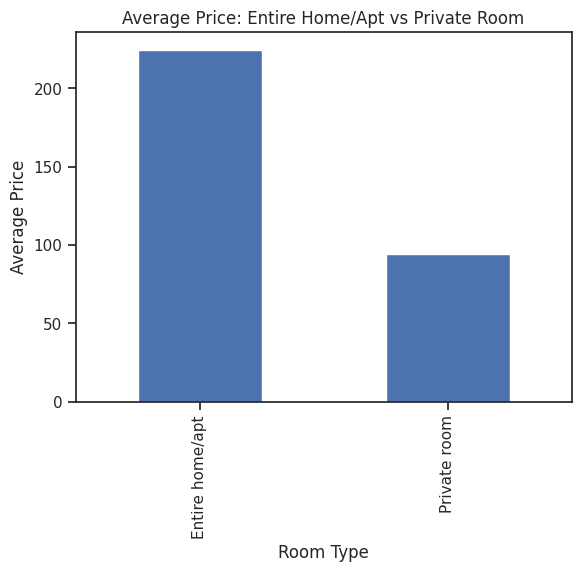

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only the two room types
df_h4 = df[df["room_type"].isin(["Entire home/apt", "Private room"])]

# Calculate average price by room type
avg_price = df_h4.groupby("room_type")["price"].mean()

# Print formatted results
for room, price in avg_price.items():
    print(f"{room}: {price:.2f}")

# Plot bar chart
avg_price.plot(kind="bar")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.title("Average Price: Entire Home/Apt vs Private Room")
plt.show()


In [ ]:


df["host_type"] = df["calculated_host_listings_count"].apply(lambda x: "multiple_listings" if x > 1 else "single_listings")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Total_Crimes,host_type
0,2539,Clean & quiet apt home by the park,2787,John,BROOKLYN,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,162387,multiple_listings
1,2595,Skylit Midtown Castle,2845,Jennifer,MANHATTAN,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,136768,multiple_listings
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,MANHATTAN,Harlem,40.80902,-73.94190,Private room,150,3,0,0,0.00,1,365,136768,single_listings
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,BROOKLYN,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,162387,single_listings
4,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,MANHATTAN,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,136768,single_listings


In [ ]:
# Calculate average price for each group
avg_price = df.groupby("host_type")["price"].mean()

# Print results
print(avg_price.round(2))

host_type
multiple_listings    145.78
single_listings      175.19
Name: price, dtype: float64


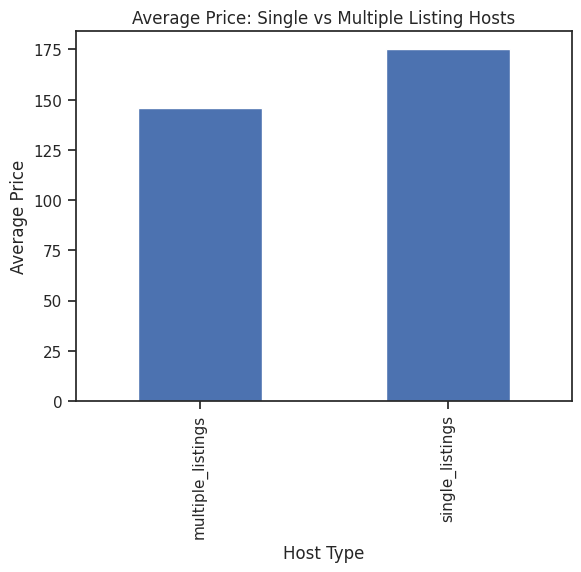

In [ ]:
# Plot bar chart
avg_price.plot(kind="bar")
plt.xlabel("Host Type")
plt.ylabel("Average Price")
plt.title("Average Price: Single vs Multiple Listing Hosts")
plt.show()

In [ ]:
df = df.drop(columns=["latitude",	"longitude"])
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Total_Crimes,host_type
0,2539,Clean & quiet apt home by the park,2787,John,BROOKLYN,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365,162387,multiple_listings
1,2595,Skylit Midtown Castle,2845,Jennifer,MANHATTAN,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,136768,multiple_listings
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,MANHATTAN,Harlem,Private room,150,3,0,0,0.00,1,365,136768,single_listings
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,BROOKLYN,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,162387,single_listings
4,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,MANHATTAN,Murray Hill,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,136768,single_listings


In [ ]:
print(df["review_group"].dtype)

KeyError: 'review_group'